Project Outline:

Step 1. collect the data, analyze the loss distribution, and create parameters to approximate using newton's method. Take those parameters to find the expected loss amount

2. define risk classes and dive further into premium estimation across each risk class. then, use those risk classes to determine claim frequency for a complete breakdown of premium analysis for policyholders.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Loading the data
df = pd.read_csv('/content/drive/Shareddrives/NumericalAnalysisProject/train.csv')

# Previews
print(df.head())

print(df.info())

print(df.describe())

Mounted at /content/drive
   id cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9  ...     cont6     cont7  \
0   1    A    B    A    B    A    A    A    A    B  ...  0.718367  0.335060   
1   2    A    B    A    A    A    A    A    A    B  ...  0.438917  0.436585   
2   5    A    B    A    A    B    A    A    A    B  ...  0.289648  0.315545   
3  10    B    B    A    B    A    A    A    A    B  ...  0.440945  0.391128   
4  11    A    B    A    B    A    A    A    A    B  ...  0.178193  0.247408   

     cont8    cont9   cont10    cont11    cont12    cont13    cont14     loss  
0  0.30260  0.67135  0.83510  0.569745  0.594646  0.822493  0.714843  2213.18  
1  0.60087  0.35127  0.43919  0.338312  0.366307  0.611431  0.304496  1283.60  
2  0.27320  0.26076  0.32446  0.381398  0.373424  0.195709  0.774425  3005.09  
3  0.31796  0.32128  0.44467  0.327915  0.321570  0.605077  0.602642   939.85  
4  0.24564  0.22089  0.21230  0.204687  0.202213  0.246011  0.432606  2763.85  

[5 rows x 132 colu

In claims data like this set given by Allstate in their claims severity competition, you tend to see several variables like cont1, cat1, and plenty of other variables. These variables are anonymized variables that reveal data about individual people. cont1, cont2, cont(x) are continuous variables, and can take on any numerical value. For example, in an auto insurance data set this could be driver age, vehicle value, policyholder credit score, time insured, company created risk score, and so on. cat1, cat2, cat(x) are categorical variables, and they take on labels and groups, not numbers. For example this could mean state, vehicle type, gender, and so on. These variables have been replaced with cont(x) and cat(x) to anonymize the data, so you can see the values and categories that cat(x) values set specific policyholder id's into to draw conclusions on the average loss amount per id, not necessarily the interpretation of the data. You can draw insights and conclusions from data without knowing what the values represent. Another reason why the variables are anonymized is for privacy reasons. The real variables are from Allstates personal proprietary business information and contain highly sensitive information about their policyholders. This could include driving history, credit card number, zip code, and plenty of other things. Releasing the data would allow people reading the data to potentially identify individuals, and data analysts could use this information to reverse engineer Allstates underwriting strategy to compete against them. Since this dataset was created based off real information from Allstate, for their competition, the information is anonymized, but still categorized to allow you to draw conclusions from it. For example, cat3 = B tends to have a higher loss (this may or may not be true, just an example of a conclusion to be potentially drawn from this dataset.)

In summary, the dataset is anonymized which limits interpretation, but it allows us to draw real world conclusions from real world data. It's actually useful for data analysts to focus on variables that could potentially be statistically significant instead of the actual variable and what it represents. For example, maybe X age drivers get into more accidents and have a higher loss amount on average. The same conclusion could be drawn that cont3 = x is positively correlated with higher loss amounts and frequencies. cont(x) are numerical values. cat(x) are categorical values. loss is the loss amount for each id. id is the policyholder id and demonstrates a claim made to an insurance company by that number id.

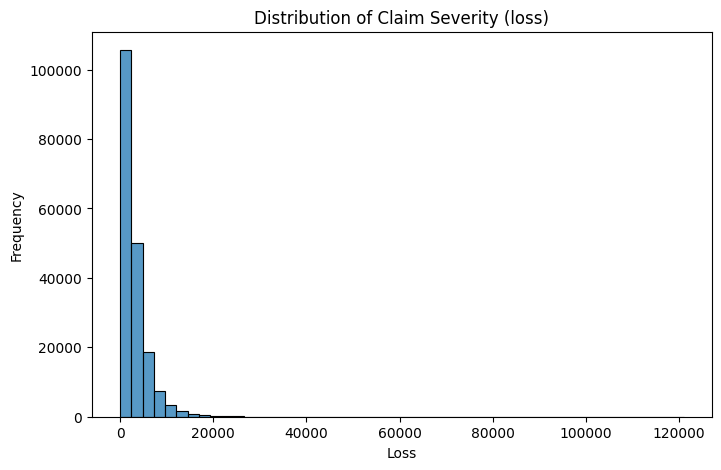

In [ ]:
#Plotting the loss distribution

plt.figure(figsize=(8,5))
sns.histplot(df['loss'], bins=50)
plt.title('Distribution of Claim Severity (loss)')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.show()

Here you see a huge spike at zero and a much longer right tail. This means that taking the log of all our values would be more valuable

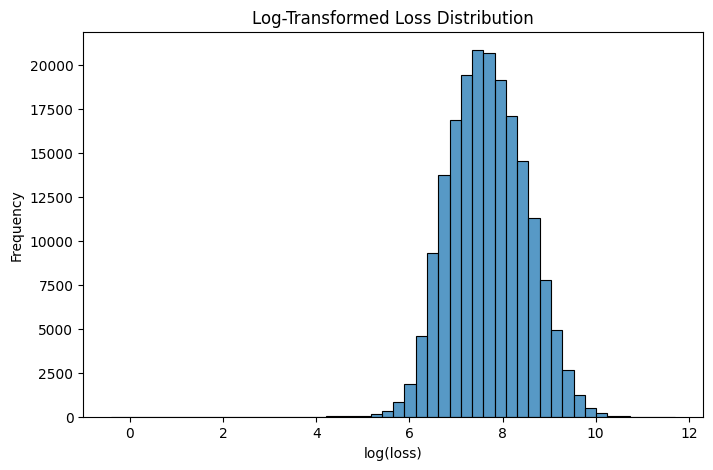

Mean: 3037.3376856699833
Median: 2115.5699999999997
Standard Deviation: 2904.0861863904365


In [ ]:
# Log Transformed Loss Distribution
plt.figure(figsize=(8,5))
sns.histplot(np.log(df['loss']), bins=50)
plt.title('Log-Transformed Loss Distribution')
plt.xlabel('log(loss)')
plt.ylabel('Frequency')
plt.show()

# Interpretation
mean_loss = df['loss'].mean()
median_loss = df['loss'].median()
std_loss = df['loss'].std()

print('Mean:', mean_loss)
print('Median:', median_loss)
print('Standard Deviation:', std_loss)


Now that we have a normal distribution (as seen by the bell curve), we know that log(loss) ~ Normal(*μ*,$σ^2$) (A.K.A., log(loss) is a random variable distributed normally with some mean and some variance sigma squared).
Therefore, the loss distribution follows a lognormal
distribution.

loss ~ Lognormal(*μ*, $σ^2$)

With this information we can use the expected loss formula for a lognormal random variable:

$E$[loss] $=e^{\mu + \frac{\sigma^2}{2}}$

Since our data follows a normal distribution, we can use our data to estimate $\mu$ and $\sigma$. With this information, we can verify $\sigma$ using Newton's Method.

For a normal distribution, the MLE (Maximum Loss Expectancy, or the worst case financial loss from a given risk) for $\sigma$ satisfies the following equation:

$f(\sigma) = \frac{1}{n}\sum\frac{(x_i - \mu)^2}{\sigma^2}-1$

Where $n$ is the number of data points where the loss amount is positive, since we are modeling *severity*, there is no severity when there is no loss amount.

For the normal model, variance already has a closed form solution and can be estimated without Newton's Method. However, rewriting the problem as a root-finding problem demonstrates how Newton's Method can be applied to estimating parameters. This means we can confirm Newton's Method worked and can still apply it to our project.



In [ ]:
# finding mu
log_loss = np.log(df[df['loss'] > 0]['loss'])
mu = log_loss.mean()
print('mu:', mu)

# Std. dev to compare to the root found std. dev
sigma_direct = log_loss.std()
print('sigma_direct:', sigma_direct)

# finding n in our data
positive_losses = df[df['loss'] > 0]
n = len(positive_losses)
print('n:', n)

mu: 7.685267842849341
sigma_direct: 0.8118680942954611
n: 188318


Since $n$ is so massive, it would take us years to solve this manually. Instead, we can use python to calculate $\frac{1}{n}\sum(x_i-\mu)^2$, and set it to $A$. Then the problem becomes

  $f(\sigma) = \frac{A}{\sigma^2} - 1$,

  Where $A$ is a constant.

  We can now take the derivative of this function and make an initial guess of 1 to find the root of $\sigma$.

In [ ]:
A = np.mean((log_loss - mu)**2) # A is the sum of all log_loss variables minus the mean squared.
print('A: ', A)

A:  0.6591263024457225


In [ ]:
# Newton's Method for finding a root
variable_dict = {'mean': mu, 'A': A, 'Root Guess': 0.0000001}

sigma = sm.Symbol('sigma', positive = True)

# Function definitions
f_sigma_sym = variable_dict['A']/sigma**2 - 1
f_sigma_prime_sym = sm.diff(f_sigma_sym, sigma)
f_sigma = sm.lambdify(sigma, f_sigma_sym, 'numpy')
f_sigma_prime = sm.lambdify(sigma, f_sigma_prime_sym, 'numpy')

root = newton(func=f_sigma, x0=variable_dict['Root Guess'], fprime=f_sigma_prime, maxiter=1000)
print('Found Root:', root)

Found Root: 0.8118659387150824


Part 1, Using Newton's Method to estimate lognormal severity variance.

We used Newton's Method to calculate the variance of a lognormal loss distribution, which we can now use to plug back into our ecpected claim size equation we wrote earlier:

$E$[loss] $=e^{\mu + \frac{\sigma^2}{2}}$

TO DO LATER ^ Newton's method iterations, d/dx of f(sigma), and plugging into the E[loss] formula

This information is extremely valuable for insurance companies looking to evaluate and estimate expected claims costs for their policyholders.


We can also calculate the expected loss of our claims by using Simpson's rule

Since expected premium is the expected severity multiplied by the expected frequency, we need to estimate the expected frequency as well.

Limitations in creating a frequency model include no time series in the data set, however we can use the given categorical variables to attempt to find correlations between groups to assign our own risk class.

ONE PARAGRAPH WRITE-UP

For our project, we decided to develop a pricing model for insurance claims by estimating the expected loss per policy. We use claim and loss amount data from Allstate's real-world anonymized dataset used in their recruitment competition in 2016. We plan to take the loss amounts from each claim and model the distribution type and use Newton's Method to validate the sigma in the loss distribution. Once we have the expected premium amount, we will use either Lagrange or Cubic Spline Interpolation to calculate the frequency between assigned risk classes for a smoother premium estimation. The result will be a pricing model that combines claim frequency and severity to approximate expected loss per policy.


In [ ]:
#finding expected loss
expected_loss = np.exp(mu + root/2)
print('Expected Loss:', expected_loss)

Expected Loss: 3265.606597012754


In [ ]:
# attempting to build a relative frequency model for groups
# need to look at average loss amount between each categorical variable and look for trends
print(df.columns) # to see all the variables to potentially group by

In [ ]:

group_cat1 = df.groupby('cat1')['loss'].agg(['count', 'mean', 'median', 'std']) # groupby splits the dataset into groups based on cat1, then we only look at the loss column for each group within cat1.
print(group_cat1)                                                               # this shows us the different groups cat1 has

We can see the ratio of the counts are about 3:1 which is good, and the mean of A is almost double the amount of B. This means cat1 is very predictive of loss. Since theres a higher mean, median, and std, we can already confirm that group A is more expensive and more volatile. We can conclude with some confidence that this variable separates risk, has a strong signal and has plenty of data. this means we have a good variable to break into frequency and severity and now the expected loss of the two groups vary. this gives us even more insight and more accuracy when estimating claims

main takeaway: policies in A have significantly higher expected losses and variability compared to B, indicating that cat1 is a strong predictor of risk and a good variable to group risk based off.

In [ ]:
# testing cat2
group_cat2 = df.groupby('cat2')['loss'].agg(['count', 'mean', 'median', 'std'])
print(group_cat2)

In [ ]:
# testing cont1 first, looking for a smooth mean across variables for a better risk class continuous variable
df['cont1_bin'] = pd.qcut(df['cont1'], q = 5) # cutting cont1 into 5 bins
group_cont1 = df.groupby('cont1_bin')['loss'].agg(['count', 'mean', 'median', 'std'])
print(group_cont1) # summary of cont1

group_cont1['mean'].plot(marker='o', title='Average Loss by cont1 bins')
plt.xlabel('cont1 bins')
plt.ylabel('Average Loss')
plt.show()

No clear trend from cont1. For risk classes we need a consistent increase or decrease in mean loss through the 5 bins

In [ ]:
df['cont2_bin'] = pd.qcut(df['cont2'], q = 5) # cutting cont2 into 5 bins
group_cont2 = df.groupby('cont2_bin')['loss'].agg(['count', 'mean', 'median', 'std'])
print(group_cont2) # summary of cont1

group_cont2['mean'].plot(marker='o', title='Average Loss by cont2 bins')
plt.xlabel('cont2 bins')
plt.ylabel('Average Loss')
plt.show()

In [ ]:
df['cont3_bin'] = pd.qcut(df['cont2'], q = 5) # cutting cont3 into 5 bins
group_cont3 = df.groupby('cont3_bin')['loss'].agg(['count', 'mean', 'median', 'std'])
print(group_cont3) # summary of cont1

group_cont3['mean'].plot(marker='o', title='Average Loss by cont3 bins')
plt.xlabel('cont3 bins')
plt.ylabel('Average Loss')
plt.show()

cont2 and cont3 are apparently the exact same variable, both with a good increase in mean as they increase. This is the perfect variable for us to use when determining risk classes. Now I am going to assign each of these bins to their own risk class so we can compute frequency for our pricing model. Once we compute the frequency, we are able to use the severity we found earlier validated by Newton's Method to compute premium. Again, premium is simply frequency multiplied by severity.

$
Premium_i = \lambda_i\cdotp E[X]
$

Where $\lambda_i$ is a poisson random variable representing relative frequency across the five risk classes, and $E[X]$ is the average loss

In [ ]:
# Assigning bins and variables to cont1
df['risk_class'] = pd.qcut(df['cont2'], q=5)
# Computing the frequency
frequency = df.groupby('risk_class')['loss'].apply(lambda x: (x > 0).mean())
# Computing severity (already found, but repeating here to group by risk class)
severity = df[df['loss'] > 0].groupby('risk_class')['loss'].mean()

Important note: for this project, frequency has been estimated, since calculating frequency requires you know the number of claims in your dataset, as well as the exposure, which we don't know for this dataset. Exposure refers to how many units of risk we observed. This could mean the total number of insurance policies, the total number of insured cars, the total number of policy years, it depends on what you are looking for. Because we don't have the total number of anything, just the claims and the loss amounts and several categorical and continuous variables, we have to assume exposure.

In [ ]:
group_cont2['count'] # tells us the total number of claims

exposure = 10000 #assumed exposure
group_cont2['lambda'] = group_cont2['count'] / exposure # each groups relative frequency
print(group_cont2[['count', 'lambda']])

The lambda should be increasing with each bin, but its not.

After lots of research I have concluded that because this dataset only contains observed claims and no exposure information, we are not able to directly estimate frequency. To combat this, we will have to assume frequency is constant across each risk class.

This means that instead of modeling premium as frequency multiplied by severity, we will have to model premium as average loss in each bin, which we have already computed. We can use these mean losses within each risk class against our previously computed severity in our lognormal distribution calculated using Newton's Method.

In [ ]:
group_cont2['premium'] = group_cont2['mean'] # calculates mean cost for each risk class

# points for interpolation
midpoints = [interval.mid for interval in group_cont2.index] # take the midpoint for interpolation instead of endpoints
premiums = group_cont2['mean'].values

#print points for interpolation
for i, (x, y) in enumerate(zip(midpoints, premiums), start=1):
  print(f"Point {i}: ({x:.8f}, {y:.8f})")

Now that we have 5 spline points, we will have 4 spline pieces:

$
S_1, S_2, S_3, S_4
$

We could do this by hand or through python, and I believe it would be cleaner to do it by hand and verify our solutions using python.

For this, we will be using CubicSpline from scipy.interpolate

In [ ]:
from scipy.interpolate import CubicSpline

# taking average loss in each bin
group_cont2 = df.groupby('cont2_bin')['loss'].agg(['count', 'mean', 'median', 'std'])
group_cont2 = group_cont2.copy()
group_cont2['premium'] = group_cont2['mean']

# bin midpoints and premiums
x = np.array([interval.mid for interval in group_cont2.index], dtype=float)
y = group_cont2['premium'].values

# printing points
points_table = pd.DataFrame({
    'Midpoint (x_i)': x,
    'Premium (y_i)': y
})

print("Cubic spline interpolation points:")
print(points_table.to_string(index=False))

# fitting the cubic spline
cs = CubicSpline(x, y, bc_type='natural') # bc_type natural tells python to use a natural cubic spline so that we can evaluate by hand like in class (2nd deriv = 0)

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = cs(x_smooth)

#plotting
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'o', markersize=8, label='Risk class premiums')
plt.plot(x_smooth, y_smooth, '-', linewidth=2, label='Natural cubic spline')
plt.title('Premium Curve by Risk Class')
plt.xlabel('Risk Score')
plt.ylabel('Premium')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

So far in our project we have used Newton's method to compute $\sigma$ in a lognormal distribution model, and we have interpolated a smooth premium curve model across different risk scores according to our dataset, now we can take both of these parameters and actually compute $E[X]$ using Simpson's Rule. This is a much more accurate way of computing the expected severity, since we are using an integrated mean of a fitted model versus the sample mean and variance of data from the lognormal distribution. We can use the maximum observed loss for the upper bound, and our fitted $\mu$ and $\sigma$ from our Newton's method to integrate the expected value:

$
E[X] = \int xf(x)dx
$

According to this source, https://towardsdatascience.com/log-normal-distribution-a-simple-explanation-7605864fb67c/, the probability density function for a lognormal distribution can be written as:

$
f(x) = \frac{1}{x\sigma\sqrt{2\pi}}e^{-\frac{(lnx-\mu)^2}{2\sigma^2}},\ \ \ \ x>0
$